# Проект: Исследование стартапов

## Введение

Обратилась компания, которая собирается выйти на рынок с прицелом на покупку, развитие и последующую перепродажу перспективных стартапов. Для разработки модели бизнеса нужна информация.

Наша задача: Понять, какие данные могут быть полезны в дальнейшем анализе и разработке бизнес модели. Все ли данные корректны и соответсвуют здравому смыслу.
Затем ответить на следующие вопросы:
- по каким столбцам можно объединять данные из разных таблиц;
- можно ли доверять данным о сотрудниках стартапов и их образовании;
- что означают покупки за 0 или за 1 доллар;
- какая цена в зависимости от категории стартапов и количества раундов финансирования перед его покупкой;
- как рассчитать и отобразить численные показатели и динамику.





## Шаг 1. Знакомство с данными: загрузка и первичная предобработка

Названия файлов:
* acquisition.csv
* company_and_rounds.csv
* people.csv
* education.csv
* degrees.csv

Опциональные датасеты:
* fund.csv
* investment.csv

In [ ]:
# Импортируем библиотеки
import pandas as pd


# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
try:
    import phik
except ModuleNotFoundError as e:
    !pip install phik
    import phik
    print("Error was:", e)

In [ ]:
to_path = '/datasets/'
# Выгружаем данные
acquisition_df = pd.read_csv(to_path + 'acquisition.csv')
com_rounds_df = pd.read_csv(to_path + 'company_and_rounds.csv')
people_df = pd.read_csv(to_path + 'people.csv')
education_df = pd.read_csv(to_path + 'education.csv')
degrees_df = pd.read_csv(to_path + 'degrees.csv')
fund_df = pd.read_csv(to_path + 'fund.csv')
investment_df = pd.read_csv(to_path + 'investment.csv')

Проверяем и исправляем столбцы в вид snake_case.
Приведем в датасете `company_and_rounds.csv` столбцы к виду snake_case. После преобразований столбцы `company_ID` и `company_id` будут идентичными, заранее переименуем один из них, чтобы исключить дубли в названиях

In [ ]:
com_rounds_df.columns

Index(['company  ID', 'name', 'category  code', 'status', 'founded  at',
       'closed  at', 'domain', 'network  username', 'country  code',
       'investment  rounds', 'funding  rounds', 'funding  total', 'milestones',
       'funding  round  id', 'company  id', 'funded  at',
       'funding  round  type', 'raised  amount', 'pre  money  valuation',
       'participants', 'is  first  round', 'is  last  round'],
      dtype='object')

In [ ]:
com_rounds_df = com_rounds_df.rename(columns={'company  ID': 'id'})
#Убрали пробелы между словами и заменили на _
com_rounds_df.columns = com_rounds_df.columns.str.strip().str.replace("  ", " ")
com_rounds_df.columns = com_rounds_df.columns.str.replace(" ", "_")

In [ ]:
com_rounds_df.head(5)

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Поменяли названия столбцов только в одном датасете `company_and_rounds.csv`. Остальные шесть датасетов в порядке, столбцы уже приведены к типу snake_case

In [ ]:
acquisition_df['term_code'].unique()
acquisition_df.dtypes

id                       int64
acquiring_company_id     int64
acquired_company_id      int64
term_code               object
price_amount             int64
acquired_at             object
dtype: object

In [ ]:
#com_rounds_df['is_first_round'].unique()

In [ ]:
display(people_df.head(5))
display(people_df.dtypes)

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


id                    int64
first_name           object
last_name            object
company_id          float64
network_username     object
dtype: object

In [ ]:
display(education_df.head(5))
display(education_df.dtypes)


,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


id               int64
person_id        int64
instituition    object
graduated_at    object
dtype: object

In [ ]:
display(degrees_df.head(5))
display(degrees_df.dtypes)

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


id              int64
object_id      object
degree_type    object
subject        object
dtype: object

- В датасете `acquisition.csv` изменим тип данных в столбцах `term_code` на категорию, столбец `acquired_at` переведем из строки в дату. Столбцы с числовыми значениями приведем к более низкому размеру хранения.
- В датасете `company_and_rounds.csv` изменим тип данных в столбцах `category_code`, `status`, `funding_round_type`, `is_first_round`, `is_last_round` на категориальный тип, а столбцы со строками дат `funded_at`, `founded_at`, `closed_at` на тип даты. `company_id` изменим к целочисленному типу.
- В `people.csv` все в порядке, изменим столбец `company_id`к целочисленному типу.
- Датасет `education.csv`с двойным идентификаторам, потом надо обработать, если датасет будет использоваться. Привести тип столбца `graduated_at` к дате.
- Датасет `degrees.csv`с двойным однотипным идентификаторам, потом надо обработать, если датасет будет использоваться. Привести столбец `object_id` к числовому типу, он совпадает со столбцом из Датасет `education.csv` по столбцу `id`

Промежуточные выводы: Датасеты с корректными названиями, кроме одного `company_and_rounds.csv`. Привели столбцы к типу snake_case. Проверили типы данных, некорректно отображаются даты, поправим на следующем этапе.

### 1.2. Смена типов и анализ пропусков


In [ ]:
#Согласно заданию обработаем типы данных в столбцах, где хранят дату
#датасет company_and_rounds.csv имеет столбцы с датами funded_at, founded_at, closed_at
for column in ['funded_at', 'founded_at', 'closed_at']:
    com_rounds_df[column] = pd.to_datetime(com_rounds_df[column])

#датасет education.csv имеет столбец с датой graduated_at
education_df['graduated_at'] = pd.to_datetime(education_df['graduated_at'])

#датасет acquisition имеет столбец с датой graduated_at
acquisition_df['acquired_at'] = pd.to_datetime(acquisition_df['acquired_at'])

In [ ]:
def show_isna(data, name):
    display(f'Пропуски в датасете: {name}')
    display((data.isna().mean()*100).round(2).sort_values(ascending=False))

#создаем словарь для датасетов
datasets = {
    'acquisition_df': acquisition_df,
    'people_df': people_df,
    'com_rounds_df': com_rounds_df,
    'education_df': education_df,
    'degrees_df': degrees_df,
    'fund_df': fund_df,
    'investment_df': investment_df
}

for name, df in datasets.items():
    show_isna(df, name)

'Пропуски в датасете: acquisition_df'

term_code               80.54
acquired_at              0.31
id                       0.00
acquiring_company_id     0.00
acquired_company_id      0.00
price_amount             0.00
dtype: float64

'Пропуски в датасете: people_df'

company_id          84.73
network_username    82.86
id                   0.00
first_name           0.00
last_name            0.00
dtype: float64

'Пропуски в датасете: com_rounds_df'

...

subject        25.83
degree_type    10.23
id              0.00
object_id       0.00
dtype: float64

'Пропуски в датасете: fund_df'

network_username      81.56
founded_at            60.48
country_code          39.47
domain                36.82
name                   0.02
id                     0.00
investment_rounds      0.00
invested_companies     0.00
milestones             0.00
dtype: float64

'Пропуски в датасете: investment_df'

id                  0.0
funding_round_id    0.0
company_id          0.0
fund_id             0.0
dtype: float64

- В датасете `acquisition.csv` о покупках одними компаниями других компаний отсутствует 80% `term_code`(вариант расчёта), 0.3% в дате сделки `acquired_at`.
Тип пропуска `term_code` критичен, он не повлияет на ИАД, тип MCAR, не связан с данными. 80% компаний каким-то образом не внесли данные по варианту расчета.
- В датасете `com_rounds_df` с информацией о компаниях и раундах финансирования отсутствует 98% `closed_at`, по 75%  в столбцах касаемо процесса сделки, данные начали накапливаться с 1998: `funding  round`, `company  id`, `funded  at`, `funding  round  type`, `raised  amount`, `pre  money  valuation`, `participants`, `is  first  round`, `is  last  round`. Это признак того, что до 1998 г. данные не собирались. Тип пропуска MAR. Но они важны для инвесторов, часть оставляем.
- В `participants` и в `pre_money_valuation` в основном стоят нули. Их удалим. Столбец `company_id` совпадает с `id`, заполним `id` недостающими значениями  и затем удалим. В остальных тоже отсутствуют данные, но в меньшем количестве: сайт компании, ник, код страны, дата инвестирования, что сейчас не важно для анализа.
- `funded_at`дата финансирования - по историческим данным много пропусков до 2003 г. Это специфика полученных данных, до 1998 велся подсчет другими способами, данные могли быть потеряны.
- В датасете `people_df` информации о сотрудниках отсутствует 82-84% данных в столбцах `company_id`, `network_username`. Тип пропуска MCAR
- В датасете `education_df` об образовании сотрудиков отсутствуют 47% данных в столбце о дате образования `graduated_at`. Это тип пропуска MCAR. Случайно пропущенные данные, они не связаны с данными об образовании из другой таблицы.
- В датасете `degrees_df` о типе образования отсутствует 25% в столбце специальность `subject` и 10% `degree_type`. Тип пропуска MCAR. Тоже не определить связь пропусков с данными.  
- В датасете `fund_df`с информацией о фондах, отсутствует тоже в большом кол-ве `network_username` - 81%, `founded_at` - 61%, `domain` и `country_code` - 36-39%.
- В датасете об этапах финансирования `investment_df` нет пропусков.

Достаточно много пропусков в значимых столбцах, касаемых процесса финансирования и сумм инвестирования в раундах в таблице `com_rounds_df`. Но почти полные данные в столбцах с итоговым финансированием `funding_total` и кол-ве раундов. Есть два дублирующих себя столбца - это `company_id`. Причем один почти без пропусков 0.14%.
Почти отсутствуют данные по вариантам расчета в датасете `acquisition.csv`, но в остальном данные целые.



In [ ]:
# 2. Заполняем пропуски в company_id значениями из funding_round_id
com_rounds_df['id'] = com_rounds_df['id'].fillna(com_rounds_df['company_id'])
#com_rounds_df = com_rounds_df.drop(columns=['company_id'])

In [ ]:
com_rounds_df.columns = com_rounds_df.columns.str.lower()
com_rounds_df

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,282847.0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56454.0,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0
217770,55477.0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56542.0,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,0.0,1.0
217771,55477.0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56543.0,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,1.0,0.0
217772,283492.0,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,...,NaN,56928.0,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0


✔️ Промежуточные выводы:
В трех таблицах `company_and_rounds.csv`, `acquisition.csv`, `education.csv` найдены столбцы с датой и типом `object`, преобразовали в правильный формат datatime. В дальнейшем анализе ,как минимум, дата из одной таблицы будет нужна.
Для исследования полноты данных получили долю пропусков по каждой таблице. Почти во всех таблицах присутствуют пропуски, от 10% до 98%. Оценили типы пропусков и полноту данных, данных достаточно для следующего анализа.
Заполнены значениями из `company_id` в `id` таблицы `company_and_rounds.csv`, чтобы получить один столбец с айди компаний и удалить столбец `company_id`.

## Шаг 2. Предобработка данных, предварительное исследование


### 2.1. Раунды финансирования по годам


In [ ]:
#Заново присвоим имя датасету company_and_rounds.csv
df = pd.read_csv(to_path+'company_and_rounds.csv')
#Убрали пробелы между словами и заменили на _
df.columns = df.columns.str.strip().str.replace("  ", " ")
df.columns = df.columns.str.replace(" ", "_")


In [ ]:
df.head(3)

,company_ID,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0


In [ ]:
#Добавим в отдельный столбец год инвестирования
df['funded_at'] = pd.to_datetime(df['funded_at'])
df['year'] = df['funded_at'].dt.year
#переведем год в int и заменим пропуски на ноль
df['year'] = df['year'].fillna(0).astype('int32')

In [ ]:
pivot_sales = pd.pivot_table(
    df,
    index='year',
    values='raised_amount',
    aggfunc = {'raised_amount': ['count','median']
               }
)

In [ ]:
pivot_sales = pivot_sales[pivot_sales['count']>50].iloc[1:]

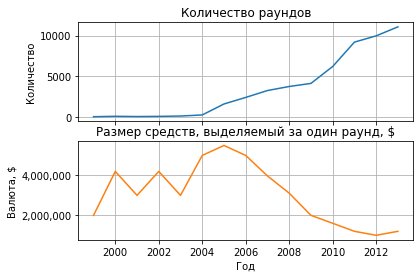

In [ ]:
# Строим график
axes = pivot_sales.plot(kind='line',
            subplots=True,
            sharex=True,
            sharey=False,
            legend=False,
            title=['Количество раундов', 'Размер средств, выделяемый за один раунд, $'])

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)

# Устанавливаем подпись для оси Y каждого из подграфиков
axes[0].set_ylabel('Количество')
axes[1].set_ylabel('Валюта, $')

# Включаем сетку для каждого из подграфиков
axes[0].grid(which='both')
axes[1].grid(which='both')

# Подписываем оси
plt.xlabel('Год')
plt.show()


В 2005 году был максимальный размер средств, выделенный за раунд. В 2013 случился пик по количеству раундов за всю историю проведения, но компании получили мало средств.


### 2.2. Люди и их образование

Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний.

- Оцените, насколько информация об образовании сотрудников полна. Используя датасеты `people.csv` и `education.csv`, разделите все компании на несколько групп по количеству сотрудников и оцените среднюю долю сотрудников без информации об образовании в каждой из групп. Обоснуйте выбранные границы групп.
- Оцените, возможно ли для выполнения задания присоединить к этим таблицам ещё и таблицу `degrees.csv`.

In [ ]:
to_path = '/datasets/'

people = pd.read_csv(to_path + 'people.csv')
education = pd.read_csv(to_path + 'education.csv')
degrees = pd.read_csv(to_path + 'degrees.csv')
display(people.shape)
display(education.shape)
display(degrees.shape)

(226709, 5)

(109610, 4)

(109610, 4)

In [ ]:
#удалим id в education, не имеет отношение к анализу
education = education.drop('id', axis=1)

In [ ]:
#people['company_id'] = pd.to_numeric(people['company_id'], errors='coerce').astype('Int32')

In [ ]:
display(people.head(12))
display(education.head(12))
display(degrees.head(5))

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN
5,100002,Keith,Kurzendoerfer,NaN,NaN
6,100006,Courtney,Homer,81558.0,jobsbostontech
7,100009,Eddy,Badrina,NaN,NaN
8,100010,Michael,Dadashyan,NaN,fbroulette
9,100011,Jeff,Grell,NaN,NaN


,person_id,instituition,graduated_at
0,6117,NaN,NaN
1,6136,"Washington University, St. Louis",1990-01-01
2,6136,Boston University,1992-01-01
3,6005,University of Greenwich,2006-01-01
4,5832,Rice University,NaN
5,1017,Northeastern University,1988-01-01
6,6176,Rochester Institute of Technology,2002-01-01
7,5412,University of Cambridge,2002-01-01
8,1243,University of Oregon,1997-01-01
9,6265,University of Pennsylvania,1989-01-01


,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [ ]:
#соединим с помощью merge два dataset: people и education
merged = pd.merge(
    people,
    education,
    left_on='id',       # Столбец из people
    right_on='person_id', # Столбец из education
    how='left'          # Left join для сохранения всех сотрудников
)
merged.head(3)

,id,first_name,last_name,company_id,network_username,person_id,instituition,graduated_at
0,10,Mark,Zuckerberg,5.0,NaN,10.0,Harvard University,NaN
1,100,Peter,Lester,27.0,NaN,NaN,NaN,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaN,NaN,NaN


Добавим столбец-признак с условием, есть ли образование или нет. Будем считать, что если заполнен столбец instituition, то работник с образованием = 1.

In [ ]:
merged['has_education'] = merged['instituition'].notna().astype('int8')

In [ ]:
# Удаляем дубликаты по связке company_id + id
df_no_duplicates = merged.drop_duplicates(subset=['company_id', 'id'])

# Проверяем результат
print(f"Было строк: {len(merged)}")
print(f"Стало строк: {len(df_no_duplicates)}")
print(f"Удалено дубликатов: {len(merged) - len(df_no_duplicates)}")

Было строк: 267694
Стало строк: 226709
Удалено дубликатов: 40985


In [ ]:
#проверка разных компаний по фильтру
df_no_duplicates[df_no_duplicates['company_id'] == 196087.0]

,id,first_name,last_name,company_id,network_username,person_id,instituition,graduated_at,has_education
233209,66727,knine,compton,196087.0,NaN,66727.0,Cypress College,1997-01-01,1


Для разделения компаний воспользуюсь практикой из бизнеса, где есть четкая структура:
- к соло-компаниям - 1 сотрудник,
- к микропредприятиям относятся организации, в которых число сотрудников не превышает 15,
- к малым - с штатом от 16 до 100 человек,
- к средним - с штатом от 100 до 250 человек
- к крупным - с штатом от 250

Тем самым выделю 5 типов компаний. В списке одна крупная компания.

In [ ]:
#Сгруппируем все компании по кол-ву сотрудников и вычислим кол-во работников с образованием

company_grouped = df_no_duplicates.groupby('company_id').agg({
    'id': 'nunique',
    'has_education': 'sum',
}).reset_index()
company_grouped.columns = ['company_id', 'employee_count', 'has_education']
company_grouped.sort_values(by='employee_count')
company_grouped['no_education_mark'] = round((1 - company_grouped['has_education']/company_grouped['employee_count']),2)
company_grouped.sort_values(by='employee_count')


,company_id,employee_count,has_education,no_education_mark
11460,70873.0,1,0.0,1.00
19251,196087.0,1,1.0,0.00
19250,196069.0,1,1.0,0.00
12231,77166.0,1,0.0,1.00
12232,77175.0,1,1.0,0.00
...,...,...,...,...
378,499.0,63,43.0,0.32
20605,231067.0,72,58.0,0.19
777,1242.0,138,101.0,0.27
25,29.0,150,110.0,0.27


In [ ]:
#С помощью функции pd.cut() категоризуем данные
company_grouped['category'] = pd.cut(company_grouped['employee_count'], bins = [0,1,16,100,240,500], labels = ["Соло", "Микро", "Малые", "Средние", "Крупные"])
#объединим по company_id в датафреймах company_grouped и основную таблицу merged
#merged_01 = pd.merge(merged, company_grouped, on='company_id', how='left')

company_grouped.head(4)

,company_id,employee_count,has_education,no_education_mark,category
0,1.0,2,1.0,0.50,Микро
1,2.0,1,1.0,0.00,Соло
2,3.0,3,2.0,0.33,Микро
3,4.0,13,12.0,0.08,Микро


В таблице company_grouped есть категориальный тип для компаний, кол-во сотрудников, индикатор, есть ли образование или нет. Теперь определим среднюю долю сотрудников без образования

In [ ]:
company_education = company_grouped.groupby('category').agg({
    'employee_count': 'count', #все записи по сотрудникам
    'no_education_mark': 'mean' #среднее по тем, у кого нет образования
    })
company_education

,employee_count,no_education_mark
category,,
Соло,18117,0.463156
Микро,4763,0.480265
Малые,39,0.392308
Средние,2,0.270000
Крупные,1,0.310000


- Достаточно данных, чтобы оценить влияние образования для соло и микро-компаний. Всего было доступно 24% от всех компаний в датасете people.
В компаниях из одного сотрудника 46% не имеют образование. В микро компаниях 48% не имеют образование, и это логично, в таких компаниях есть персонал, который нанимают без во. В малых компаниях 39% не имеют обазование, а в средних и  крупных компаниях - только 27-31% не имеют образования.

In [ ]:
#Да, возможно присоединить датасет
#`degrees.csv` по `object_id` после преобразования столбца в int без спец.символов p:.
degrees['object_id'] = degrees['object_id'].str[2:]
degrees['object_id'] = pd.to_numeric(degrees['object_id'])
education['person_id'] = pd.to_numeric(education['person_id'])

df_full = pd.merge(education, degrees, how="inner", left_on="person_id", right_on = "object_id")
df_full.head(2)

,person_id,instituition,graduated_at,id,object_id,degree_type,subject
0,6117,NaN,NaN,1,6117,MBA,NaN
1,6136,"Washington University, St. Louis",1990-01-01,2,6136,BA,"English, French"


### 2.3. Объединять или не объединять — вот в чём вопрос


In [ ]:
display(people_df.head(3))
display(com_rounds_df.head(3))
display(fund_df.head(3))

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN


,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0


,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0


In [ ]:
#приведем столбцы к нижнему регистру
df['network_username'] = df['network_username'].str.lower()
people_df['network_username'] = people_df['network_username'].str.lower()

In [ ]:
#Проверим на уникальность значений в датасетах, если будет происходить объединение,то ключ должен быть почти уникальным
total = len(people_df['network_username'])
unique = people_df['network_username'].nunique()
print(f"people: {unique} уникальных значений из {total} ({round(unique/total*100, 1)}%)")

people: 38384 уникальных значений из 226709 (16.9%)


In [ ]:
total = len(df['network_username'])
unique = df['network_username'].nunique()
print(f"com_rounds_df: {unique} уникальных значений из {total} ({round(unique/total*100, 1)}%)")

com_rounds_df: 79374 уникальных значений из 217774 (36.4%)


In [ ]:
total = len(fund_df['network_username'])
unique = fund_df['network_username'].nunique()
print(f"fund_df: {unique} уникальных значений из {total} ({round(unique/total*100, 1)}%)")

fund_df: 2098 уникальных значений из 11652 (18.0%)


In [ ]:
# Общие значения com_rounds_df['network_username'] и people_df['network_username']
common_usernames = set(com_rounds_df['network_username'].dropna()) & set(people_df['network_username'].dropna())
print(f"Общих значений: {len(common_usernames)}")

Общих значений: 1787


In [ ]:
# Общие значения fund_df['network_username'] и people_df['network_username']
common_usernames = set(fund_df['network_username'].dropna()) & set(people_df['network_username'].dropna())
print(f"Общих значений: {len(common_usernames)}")

Общих значений: 72


- Выяснили, что от 70% повторяющихся значений по столбцу `network_username`. Имена в столбце дублируются во всех датасетах, и если проверить пересечения между датасетами, то окажется менее 10% будут пересекаться. Из-за дублей в имене `network_username`, могут появитсья множественные задвоения, если соединять данные только по этому столбцу.
- Столбец `network_username` не подходит для объединения.


### 2.4. Проблемный датасет и причина возникновения пропусков

Во время собственного анализа данных у заказчика больше всего вопросов возникло к датасету `company_and_rounds.csv`. В нём много пропусков как раз в информации о раундах, которая заказчику важна.

- Любым удобным способом приведите данные в вид, который позволит в дальнейшем проводить анализ в разрезе отдельных компаний. Обратите внимание на структуру датасета, порядок и названия столбцов, проанализируйте значения.

По гипотезе заказчика данные по компаниям из этой таблицы раньше хранились иначе, более удобным для исследования образом.

- Максимальным образом сохраняя данные, сохранив их связность и исключив возможные возникающие при этом ошибки, подготовьте данные так, чтобы удобно было отобрать компании по параметрам и рассчитать показатели из расчёта на одну компанию без промежуточных агрегаций.

In [ ]:
display(com_rounds_df.head(5))
display((com_rounds_df.isna().mean()*100).round(2))

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


id                      0.00
name                    0.14
category_code          33.93
status                  0.14
founded_at             49.51
closed_at              98.42
domain                 32.43
network_username       56.13
country_code           50.13
investment_rounds       0.14
funding_rounds          0.14
funding_total           0.14
milestones              0.14
funding_round_id       75.70
company_id             75.70
funded_at              75.81
funding_round_type     75.70
raised_amount          75.70
pre_money_valuation    75.70
participants           75.70
is_first_round         75.70
is_last_round          75.70
dtype: float64

- Просмотрим каждый столбец датасета. Столбец `name` с минимальными пропусками, название компании. По нему будем собирать новую таблицу.
- Поле `category_code` тоже оставляем, это категориальный тип, правда, с 33% пропусками. Пропуски заполним значением "na". Оптимизируем на категорию.
- Поле `status` в порядке. Пропуски заменим на 'na'. Делаем так, чтобы не было пустых ячеек. Оптимизируем на категорию.
- В столбце `founded_at` оставим год.
- Столбец `closed_at` с 98% пропусков, удалим его. Он не влияет на бизнес-задаччи, компании которые закрылись, тоже получили опыт финансирования.
- У `domain` 32% пропусков, оставим, это может быть не ошибка, а признак, что компания не позиционирует себя в сети, если микро-компания. Добавим для пустых строчку "no data".
- Добавим к `network_username`, `country_code` = `country` - "no data".
- `investment_rounds`,`funding_rounds`, `funding_total`, `milestones` с 0.14% пропусков, будто из одной системы выгрузки. Важные столбцы для анализа финансирования компаний.  
- Остальные столбцы с 75% пропусков, часть из них дублирующей информацией, например, это `company_id`, `funding_total` = это сумма `raised_amount`, а категорию финансирования `funding_round_type` удалю, непонятно как его использовать в сводной таблице. В `participants` и в `pre_money_valuation` в основном стоят нули.
- Все равно никакой информации не получим. Оставим `is first round`, `is last round` информацию о раундах. Раннее выяснили, что данные активно заполнялись для компаний с 1998 г.

Разделим датасет на две части, исходя из названия это были две таблицы с компаниями и раундами. Там, где 75% относится ко второй таблице по раундом.

In [ ]:
#Заполним выбранные столбцы значением-пустышкой и изменим object на category, понизим размерность числовых столбцов
com_rounds_df['category_code'] = com_rounds_df['category_code'].fillna('nd').astype('category')
com_rounds_df['status'] = com_rounds_df['status'].fillna('nd').astype('category')
com_rounds_df['domain'] = com_rounds_df['domain'].fillna('nd')
com_rounds_df['network_username'] = com_rounds_df['network_username'].fillna('nd')
com_rounds_df['country_code'] = com_rounds_df['country_code'].fillna('nd')
com_rounds_df['is_first_round'] = com_rounds_df['is_first_round'].fillna('nd').astype('category')
com_rounds_df['is_last_round'] = com_rounds_df['is_last_round'].fillna('nd').astype('category')


In [ ]:
#Заменим в 'funded_at' годом, чтобы заполнить пустые строки
com_rounds_df['founded_at'] = com_rounds_df['founded_at'].fillna('1800-01-01')
com_rounds_df['founded_at'] = pd.to_datetime(com_rounds_df['founded_at'])
com_rounds_df['founded_at'] = com_rounds_df['founded_at'].dt.year
com_rounds_df['founded_at'] = com_rounds_df['founded_at'].astype('int16')

In [ ]:
#Заменим в 'closed_at' годом, чтобы заполнить пустые строки
com_rounds_df['closed_at'] = com_rounds_df['closed_at'].fillna('-1')
com_rounds_df

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,1800,-1,flektor.com,nd,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,nd,nd
4,100.0,There,games_video,acquired,1800,-1,there.com,nd,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,nd,nd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,282847.0,NaN,nd,nd,1800,-1,nd,nd,nd,NaN,...,NaN,56454.0,282847.0,2011-01-31,other,5500000.0,0.0,0.0,1.0,1.0
217770,55477.0,NaN,nd,nd,1800,-1,nd,nd,nd,NaN,...,NaN,56542.0,55477.0,2011-01-13,venture,10633300.0,0.0,0.0,0.0,1.0
217771,55477.0,NaN,nd,nd,1800,-1,nd,nd,nd,NaN,...,NaN,56543.0,55477.0,2012-05-31,venture,2125720.0,0.0,0.0,1.0,0.0
217772,283492.0,NaN,nd,nd,1800,-1,nd,nd,nd,NaN,...,NaN,56928.0,283492.0,2013-12-03,venture,3602480.0,0.0,5.0,1.0,1.0


In [ ]:
#Теперь в столбце 'founded_at' год есть, заменим на no data там, где нет данных
com_rounds_df['founded_at'] = com_rounds_df['founded_at'].replace(1800, -1)

In [ ]:
#Поделим на два датасета
companies = com_rounds_df[['id', 'name', 'category_code', 'status', 'founded_at', 'closed_at',
       'domain', 'network_username', 'country_code', 'investment_rounds',
       'funding_rounds', 'funding_total', 'milestones']]
rounds = com_rounds_df[['id', 'name', 'funding_round_id',
       'funded_at', 'funding_round_type', 'raised_amount',
       'pre_money_valuation', 'participants', 'is_first_round',
       'is_last_round']]

In [ ]:
display(companies.head(3))
display(rounds.head(3))

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
0,1.0,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
1,1.0,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
2,1.0,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0


,id,name,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,888.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,889.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,2312.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0


In [ ]:
#Отберем строки только с известными названиями компаний
final_companies = companies[~companies['name'].isna()]
final_rounds = rounds[~rounds['name'].isna()]

In [ ]:
#Сгруппируем по имени компании
# Группировка по company_id с агрегацией
company_stats = final_companies.groupby('name').agg({
    'id': 'first',
    'category_code': 'first',
    'status': 'first',
    'founded_at': 'first',
    'closed_at': 'first',
    'domain': 'first',
    'network_username':'first',
    'country_code': 'first',
    'investment_rounds': 'max',
    'funding_rounds':'max',
    'funding_total': 'max',
    'milestones':'max'
}).reset_index()

In [ ]:
rounds_stats = final_rounds.groupby('name').agg({
    'id': 'first',
    'funding_round_id': 'max',
    'funded_at': 'first',
    'funding_round_type': 'first',
    'raised_amount': 'max',
    'pre_money_valuation': 'max',
    'participants':'max',
    'is_first_round': 'first',
    'is_last_round': 'first'
}).reset_index()

In [ ]:
company_stats = company_stats.sort_values('id')
rounds_stats = rounds_stats.sort_values('id')

In [ ]:
display(company_stats.info())
display(rounds_stats.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196506 entries, 177865 to 159161
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   name               196506 non-null  object 
 1   id                 196506 non-null  float64
 2   category_code      196506 non-null  object 
 3   status             196506 non-null  object 
 4   founded_at         196506 non-null  int16  
 5   closed_at          196506 non-null  object 
 6   domain             196506 non-null  object 
 7   network_username   196506 non-null  object 
 8   country_code       196506 non-null  object 
 9   investment_rounds  196506 non-null  float64
 10  funding_rounds     196506 non-null  float64
 11  funding_total      196506 non-null  float64
 12  milestones         196506 non-null  float64
dtypes: float64(5), int16(1), object(7)
memory usage: 19.9+ MB


None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196506 entries, 177865 to 159161
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   name                 196506 non-null  object        
 1   id                   196506 non-null  float64       
 2   funding_round_id     31707 non-null   float64       
 3   funded_at            31507 non-null   datetime64[ns]
 4   funding_round_type   31707 non-null   object        
 5   raised_amount        31707 non-null   float64       
 6   pre_money_valuation  31707 non-null   float64       
 7   participants         31707 non-null   float64       
 8   is_first_round       196506 non-null  object        
 9   is_last_round        196506 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(4)
memory usage: 16.5+ MB


None

In [ ]:
#Понизим размерность типов данных
company_stats['id'] = company_stats['id'].astype('int32')
company_stats['investment_rounds'] = company_stats['investment_rounds'].astype('float16')
company_stats['funding_rounds'] = company_stats['funding_rounds'].astype('float32')
company_stats['milestones'] = company_stats['milestones'].astype('float16')

rounds_stats['id'] = rounds_stats['id'].astype('int32')
rounds_stats['funding_round_id'] = rounds_stats['funding_round_id'].astype('float16')
rounds_stats['participants'] = rounds_stats['participants'].astype('float16')

In [ ]:
display(company_stats.info())
display(rounds_stats.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196506 entries, 177865 to 159161
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   name               196506 non-null  object 
 1   id                 196506 non-null  int32  
 2   category_code      196506 non-null  object 
 3   status             196506 non-null  object 
 4   founded_at         196506 non-null  int16  
 5   closed_at          196506 non-null  object 
 6   domain             196506 non-null  object 
 7   network_username   196506 non-null  object 
 8   country_code       196506 non-null  object 
 9   investment_rounds  196506 non-null  float16
 10  funding_rounds     196506 non-null  float32
 11  funding_total      196506 non-null  float64
 12  milestones         196506 non-null  float16
dtypes: float16(2), float32(1), float64(1), int16(1), int32(1), object(7)
memory usage: 16.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 196506 entries, 177865 to 159161
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   name                 196506 non-null  object        
 1   id                   196506 non-null  int32         
 2   funding_round_id     31707 non-null   float16       
 3   funded_at            31507 non-null   datetime64[ns]
 4   funding_round_type   31707 non-null   object        
 5   raised_amount        31707 non-null   float64       
 6   pre_money_valuation  31707 non-null   float64       
 7   participants         31707 non-null   float16       
 8   is_first_round       196506 non-null  object        
 9   is_last_round        196506 non-null  object        
dtypes: datetime64[ns](1), float16(2), float64(2), int32(1), object(4)
memory usage: 13.5+ MB


None

In [ ]:
display(company_stats.head(3))
display(rounds_stats.head(3))

,name,id,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones
177865,Wetpaint,1,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0
6217,AdventNet,2,enterprise,operating,1996,-1,adventnet.com,manageengine,USA,0.0,0.0,0.0,0.0
183696,Zoho,3,software,operating,2005,-1,zoho.com,zoho,USA,0.0,0.0,0.0,5.0


,name,id,funding_round_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
177865,Wetpaint,1,2312.0,2005-10-01,series-a,25000000.0,0.0,4.0,0.0,1.0
6217,AdventNet,2,NaN,NaT,None,NaN,NaN,NaN,nd,nd
183696,Zoho,3,NaN,NaT,None,NaN,NaN,NaN,nd,nd



## Шаг 3. Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных

Объедините данные для ответа на вопросы заказчика, которые касаются интересующих его компаний. Заказчика прежде всего интересуют те компании, которые меняли или готовы менять владельцев. Получение инвестиций или финансирования, по мнению заказчика, означает интерес к покупке или продаже компании.

В качестве основы для объединённой таблицы возьмите данные из обработанного датасета `company_and_rounds.csv` — выберите только те компании, у которых указаны значения `funding_rounds` или `investment_rounds` больше нуля, или те, у которых в колонке `status` указано `acquired`. В результирующей таблице должно получиться порядка 40 тысяч компаний.

Проверьте полноту и корректность получившейся таблицы. Далее работайте только с этими данными.

In [ ]:
#funding_rounds или investment_rounds больше нуля, или те, у которых в колонке status указано acquired
filtered_companies = company_stats[
    (company_stats['funding_rounds'] > 0) |
    (company_stats['investment_rounds'] > 0) |
    (company_stats['status'] == 'acquired')
]
filtered_companies.shape

(40747, 13)


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

- По предобработанному столбцу `funding_total` графическим способом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.
- В процессе расчёта значений обратите внимание, например, на показатели, возвращаемые методом `.describe()`, — объясните их. Применимы ли к таким данным обычные способы нахождения типичных значений?

Для начала определим какой размер общего финансирования для одной компаниии будет типичным.
Методика определения нормальности будет заключаться в применении статистических методов.
Исключим компании, в которых не было финансирования.
Построим гистаграмму, проанализируем ящик с усами и исключим аномальные выбросы.

<AxesSubplot:>

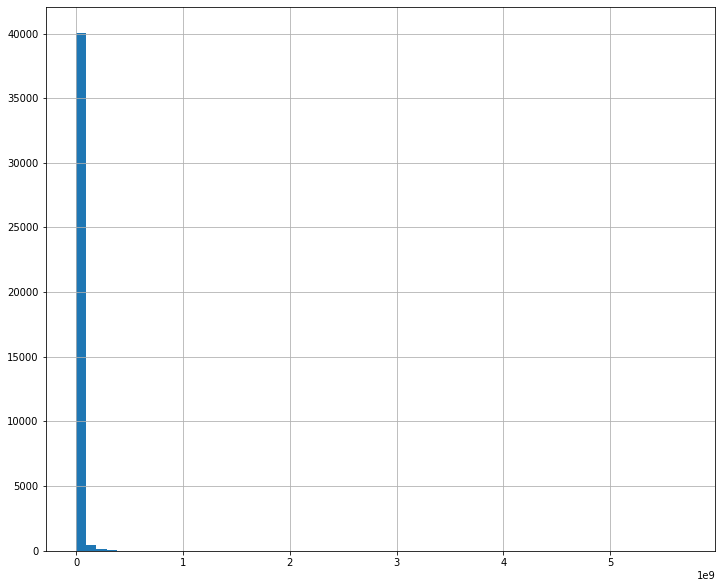

In [ ]:
#Гистограмма распределения для размера финансирования
filtered_companies['funding_total'].hist(
    figsize=(12, 10), bins = 60
)

В первом приближении видно, что большая часть компаний получает небольшое финансирование или не получает финансирование совсем, дальше выясним подробнее, найдем вилку значений. Также видно , что есть выбросы с большими суммами, что требует отдельного исследования. Выделим аномальные значения в другую группу.

In [ ]:
#все компании
display('Все выбранные компании')
display(filtered_companies['funding_total'].describe(percentiles=[0.99]))
#примерная группа компаний с большими суммами
display('Компании с выбросами')
companies_oversum = filtered_companies[filtered_companies['funding_total']>2.550878e+07]
display(companies_oversum['funding_total'].describe(percentiles=[0.99]))

'Все выбранные компании'

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
50%      6.000000e+05
99%      1.339487e+08
max      5.700000e+09
Name: funding_total, dtype: float64

'Компании с выбросами'

count    3.612000e+03
mean     8.439375e+07
std      1.721839e+08
min      2.555020e+07
50%      4.802500e+07
99%      5.859751e+08
max      5.700000e+09
Name: funding_total, dtype: float64

'Компании без выбросов'

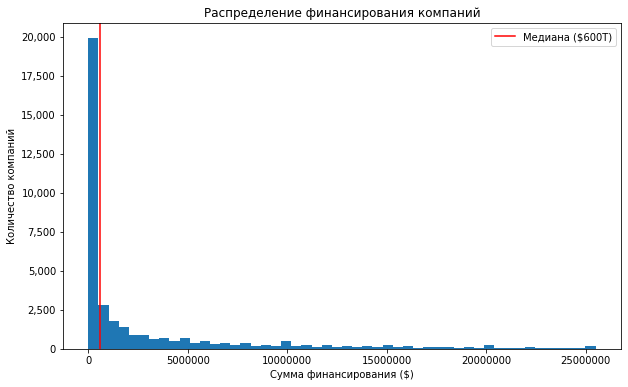

In [ ]:
display('Компании без выбросов')
companies_lowersum = filtered_companies[filtered_companies['funding_total']<2.550878e+07]

plt.figure(figsize=(10, 6))
plt.hist(companies_lowersum['funding_total'].clip(0, 2e8), bins=50)
plt.axvline(6.0e05, color='red', label='Медиана ($600T)')
#plt.axvline(1.7e8, color='orange', label='99-й перцентиль ($175M)')

plt.ticklabel_format(style="plain", axis="x")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)

plt.title('Распределение финансирования компаний')
plt.xlabel('Сумма финансирования ($)')
plt.ylabel('Количество компаний')
plt.legend()
plt.show()

Исходя из статистических параметров, получаем, что большая часть компаний не получатают финансирование, 50% компаний с финансированием в 600 тыс долл. Размах в данных примерно в 56 млн долл. Это указывает на выбросы. Медиана и среднее различаются в два порядка, что тоже указывает на длинный хвост вправо. Отдельно рассмотрим выбросы, и даже в этой группе размах в 172 млн долл.

<AxesSubplot:>

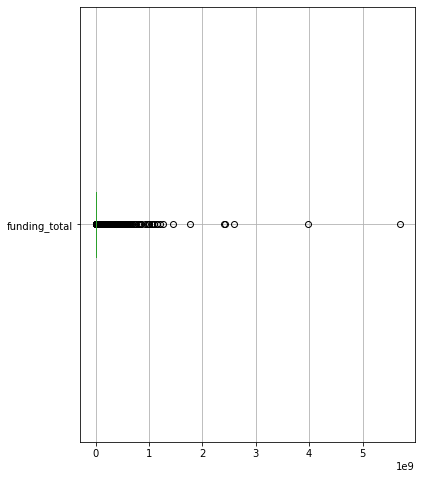

In [ ]:
#Строим диаграмму размаха методом boxplot() для компаний
filtered_companies.boxplot(column='funding_total',
                     vert=False,
                     figsize=(6, 8)
                     )

Верхний ус (правый край): 14126625.00


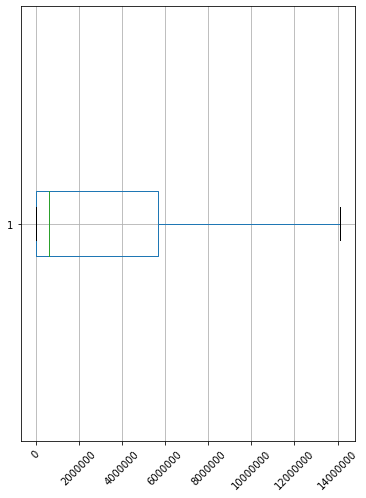

In [ ]:
# Строим диаграмму размаха методом boxplot() для компаний
filtered_companies.boxplot(column='funding_total',
                     vert=False,
                     figsize=(6, 8),
                     showfliers=False
                          )

plt.xticks(rotation=45)  # Поворот подписей оси X
plt.ticklabel_format(style="plain", axis="x")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)

# Расчет квантилей и IQR
Q1 = filtered_companies['funding_total'].quantile(0.25)
Q3 = filtered_companies['funding_total'].quantile(0.75)
IQR = Q3 - Q1

# Верхний ус (максимальное значение, не считая выбросов)
upper_whisker = Q3 + 1.5 * IQR

print(f"Верхний ус (правый край): {upper_whisker:.2f}")


- С помощью метода describe() и построения диаграммы размаха выяснили какой размер финансирования получают компании: медиана значений = 600 тысяч,а среднее 14,8 млн, сильно скошено вправо, что значит, небольшое кол-во компаний-китов получают финансирование в несколько раз больше. Это доказывает и высокое значение среднеквад.отклонения в 67 млн.
- В нашем случае для определения типичного финансирования для одной компании  следует взять медиану,которая равна 600 тысяч долл. Выбросы будем считать исходя из диаграммы размаха, по границе крайнего правого уса = 14 млн $. Это 3413 компаний.
- Если обратиться к ппроцентелю 99. Еще на порядок выше суммы финансирования, которые надо отразить в отчете.

Для типичности размера общего финансирования воспользуемся расчетами для построения диаграммы размаха. Исходя из диаграммы типичными значениями будут суммы от 0 до 14 млн долл. Суммы больше значения 14 млн долл. уже нетипичные для компаний.

Расмотрены статистические параметры у трех групп: 1.у всех компаний, 2.с финасированием, 3.с высокими ценами от 26 млн долл. В каждой группе типичен высокий средний размах и разница между средним и медианой. Данные разнородные. Можно использовать , только с применением доп. метрик, без использования среднего значения.


### 3.3. Куплены забесплатно?

- Исследуйте компании, которые были проданы за ноль или за один доллар, и при этом известно, что у них был ненулевой общий объём финансирования.

- Рассчитайте аналитически верхнюю и нижнюю границу выбросов для столбца `funding_total` и укажите, каким процентилям границы соответствуют.

In [ ]:
#Данные о покупках компаний хранятся в acquisition.csv
#Добавим информацию о покупках в основной файл с отобранными компаниями
acquisition_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9407 non-null   int64         
 1   acquiring_company_id  9407 non-null   int64         
 2   acquired_company_id   9407 non-null   int64         
 3   term_code             1831 non-null   object        
 4   price_amount          9407 non-null   int64         
 5   acquired_at           9378 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 441.1+ KB


In [ ]:
filtered = pd.merge(filtered_companies, acquisition_df , how="left", left_on="id", right_on = "acquired_company_id")
filtered.columns

Index(['name', 'id_x', 'category_code', 'status', 'founded_at', 'closed_at',
       'domain', 'network_username', 'country_code', 'investment_rounds',
       'funding_rounds', 'funding_total', 'milestones', 'id_y',
       'acquiring_company_id', 'acquired_company_id', 'term_code',
       'price_amount', 'acquired_at'],
      dtype='object')

In [ ]:
#Оставим нужные столбцы для анализа
filtered_comp = filtered[['id_x', 'name', 'category_code', 'status', 'founded_at', 'closed_at',
       'domain', 'network_username', 'country_code', 'acquiring_company_id', 'investment_rounds',
       'funding_rounds', 'funding_total', 'milestones',
       'price_amount', 'acquired_at']]

In [ ]:
filtered_comp.rename(columns={'id_x': 'id'}, inplace=True)

/opt/conda/lib/python3.9/site-packages/pandas/core/frame.py:4441: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [ ]:
filtered_comp.head(3)

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,acquiring_company_id,investment_rounds,funding_rounds,funding_total,milestones,price_amount,acquired_at
0,1,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,NaN,0.0,3.0,3.975000e+07,5.0,NaN,NaT
1,4,Digg,news,acquired,2004,-1,digg.com,digg,USA,20953.0,0.0,4.0,4.500000e+07,8.0,500000.0,2012-07-12
2,5,Socialnet,social,ipo,2004,-1,socialnet.com,socialnet,USA,NaN,3.0,11.0,2.425700e+09,5.0,NaN,NaT


In [ ]:
#Проверим на явные дубли после объединения
# Удаляем дубликаты id
acqisition_clear = filtered_comp.drop_duplicates(subset=['id'])

# Проверяем результат
print(f"Было строк: {len(filtered_comp)}")
print(f"Стало строк: {len(acqisition_clear)}")
print(f"Удалено дубликатов: {len(filtered_comp) - len(acqisition_clear)}")

Было строк: 40890
Стало строк: 40747
Удалено дубликатов: 143


In [ ]:
#Оставим в 'acquired_at' год закрытия

# Создаем копию
df_processed = acqisition_clear.copy()

# Заполняем пропуски и преобразуем даты
df_processed['acquired_at'] = pd.to_datetime(
    df_processed['acquired_at'].fillna('1800-01-01'),
    errors='coerce'
)

# Извлекаем год
df_processed['acquired_at'] = df_processed['acquired_at'].dt.year.astype('int16')
df_processed.sort_values('funding_total', ascending=True).head(3)

acqisition_clear = df_processed

In [ ]:
#Оставим компании с ненулевым финансированием проданных за 0 или 1 доллар
low_acqisition = acqisition_clear[
    (acqisition_clear['funding_total'] > 0) &
    ((acqisition_clear['price_amount'] == 0)|
     (acqisition_clear['price_amount'] == 1))
]
low_acqisition.sort_values(by = 'funding_total', ascending=False).head(5)

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,acquiring_company_id,investment_rounds,funding_rounds,funding_total,milestones,price_amount,acquired_at
4184,13219,Clearwire,mobile,acquired,2003,-1,clearwire.com,nd,USA,3827.0,0.0,4.0,5.700000e+09,2.0,0.0,2012
20288,68409,Fanatics,ecommerce,acquired,1995,-1,fanaticsinc.com,Fans,USA,28712.0,0.0,2.0,3.950000e+08,1.0,0.0,2011
10977,36886,Horizon Wind Energy,cleantech,acquired,1998,-1,horizonwind.com,nd,USA,272107.0,0.0,2.0,3.180000e+08,1.0,0.0,2007
23058,84079,Liberty Dialysis,health,acquired,-1,-1,libertydialysis.com,nd,USA,66855.0,0.0,1.0,3.149600e+08,1.0,0.0,2011
10986,36920,"RetailMeNot, Inc.",web,acquired,2007,-1,retailmenot.com,retailmenotinc,USA,36920.0,0.0,5.0,2.995000e+08,2.0,0.0,2010


In [ ]:
low_acqisition['price_amount'].value_counts()

0.0    1584
Name: price_amount, dtype: int64

Проанализируем компании, которые были куплены за 0 или 1 доллар с ненулевым объемом финансирования. Посчитаем кол-во таких компаний по категории, годам, инвест.раундам, раундам финансирования, суммы инвестирований

1. Распределение финансирования
2. топ-15 компаний по сумме инвестирований, нижняя и верхняя граница суммарного финансирования
2. по категориях число сделок/суммарное финансирование
3. по годам закрытия сделок: динамика
5. Сколько раундов типично

In [ ]:
display(low_acqisition['funding_total'].describe(percentiles=[0.9, 0.95, 0.99]))

count    1.584000e+03
mean     1.785964e+07
std      1.456660e+08
min      3.750000e+03
50%      6.000000e+06
90%      3.259156e+07
95%      5.089250e+07
99%      1.274931e+08
max      5.700000e+09
Name: funding_total, dtype: float64

In [ ]:
#Выведем топ компаний , купленных за суммы, выходящие за верхний лимит (35 млн долл)
low_acqisition[low_acqisition['funding_total']>3.259156e+07].sort_values('funding_total', ascending=False).head(5)

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,acquiring_company_id,investment_rounds,funding_rounds,funding_total,milestones,price_amount,acquired_at
4184,13219,Clearwire,mobile,acquired,2003,-1,clearwire.com,nd,USA,3827.0,0.0,4.0,5.700000e+09,2.0,0.0,2012
20288,68409,Fanatics,ecommerce,acquired,1995,-1,fanaticsinc.com,Fans,USA,28712.0,0.0,2.0,3.950000e+08,1.0,0.0,2011
10977,36886,Horizon Wind Energy,cleantech,acquired,1998,-1,horizonwind.com,nd,USA,272107.0,0.0,2.0,3.180000e+08,1.0,0.0,2007
23058,84079,Liberty Dialysis,health,acquired,-1,-1,libertydialysis.com,nd,USA,66855.0,0.0,1.0,3.149600e+08,1.0,0.0,2011
10986,36920,"RetailMeNot, Inc.",web,acquired,2007,-1,retailmenot.com,retailmenotinc,USA,36920.0,0.0,5.0,2.995000e+08,2.0,0.0,2010


В 2012 произошла сделка за 0 долларов в категории mobile с самым большим финансированием за все время по текущим данным.

Среднее больше, чем медиана, значит, есть высокое финансирование у ряда компаний. Среднее квадратичное в 145 млн. Это подтверждает, что есть длинный хвост вправо.

<div>

- Около 50 процентов компаний получили финансирование в размере 6 млн$

- Более 95 процентов компаний получили финансирование в размере 51 млн $.
    
- Около 99 процентов компаний получили финансирование в размере 127 млн$


</div>

In [ ]:
#Рассчитаем аналитически верхнюю и нижнюю границу выбросов для столбца funding_total

# Вычисляем квартили Q1 и Q3
Q1 = low_acqisition['funding_total'].quantile(0.25)
Q3 = low_acqisition['funding_total'].quantile(0.75)

# Вычисляем межквартильный размах IQR
IQR = Q3 - Q1

# Определяем пороги для выбросов
lower_bound = Q3 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижняя граница выбросов: {lower_bound:.2f}")
print(f"Верхняя граница выбросов: {upper_bound:.2f}")

Нижняя граница выбросов: -4700000.00
Верхняя граница выбросов: 35500000.00


Границы выбросов:

Нижняя: -4.75e+06 (но реальный минимум = 3750, поэтому нижних выбросов нет)
Верхняя: 3.5e+07 (≈35 млн)

Соответствие перцентилям: Верхняя граница (35M) близка к 90-му перцентилю. Все значения >35M можно считать статистическими выбросами

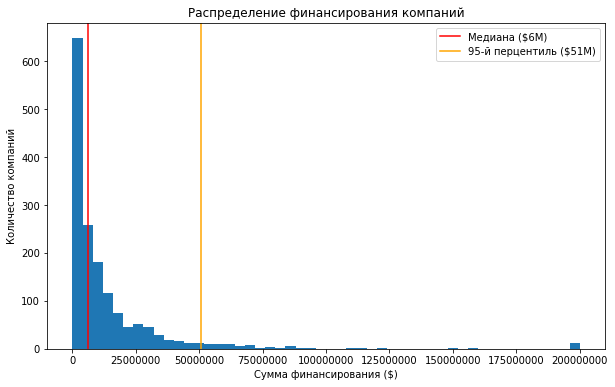

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(low_acqisition['funding_total'].clip(0, 2e8), bins=50)
plt.axvline(6e6, color='red', label='Медиана ($6M)')
plt.axvline(5.08e7, color='orange', label='95-й перцентиль ($51M)')

plt.ticklabel_format(style="plain", axis="x")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)

plt.title('Распределение финансирования компаний')
plt.xlabel('Сумма финансирования ($)')
plt.ylabel('Количество компаний')
plt.legend()
plt.show()


И гистаграмма подтверждает, что 50% компаний финансируется на 6 млн. долл.  

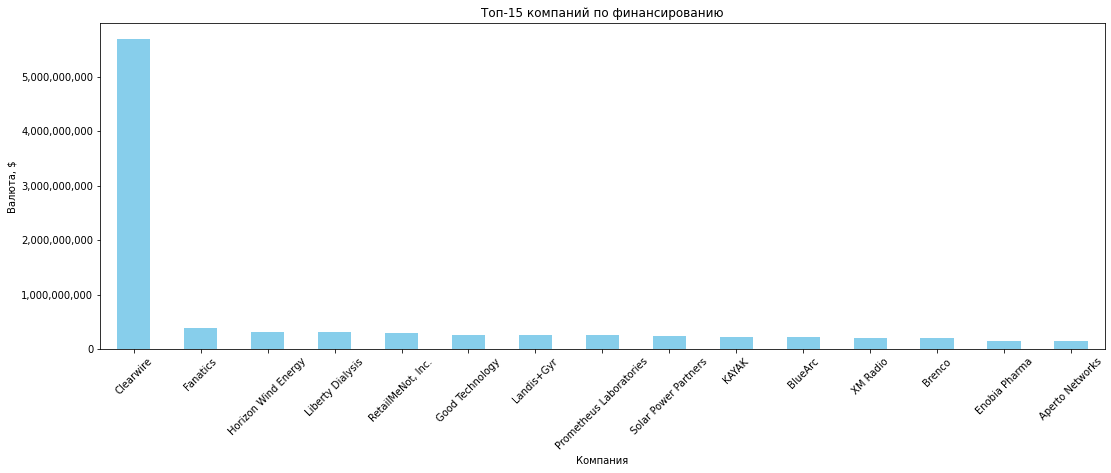

In [ ]:
#топ-15 компаний по сумме инвестирований
top15 = low_acqisition[['name', 'funding_total']].sort_values('funding_total', ascending=False)

#Построим столбчатую диаграмму
top15.head(15).plot(kind='bar',
                title='Топ-15 компаний по финансированию',
                legend=False,
                figsize=(18, 6),
                x='name',
                y='funding_total',
                ylabel='Валюта, $',
                xlabel='Компания',
                rot=45,
                color='skyblue')

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)


plt.show()

Из данных одна компания выбивается в суммарном финансировании компаний. В основном, более 50% компаний покупают за 0 долл. при суммарном финансировании в 6 млн долл. И только 10% компаний получили > $33 млн.

   1% компаний получили от $ 175 млн. до $ 5 млрд.долларов

In [ ]:
# Группировка по категориям
category_stats = low_acqisition.groupby('category_code').agg(
    num_deals=('name', 'count'),
    total_funding=('funding_total', 'sum')
).sort_values(by = 'total_funding', ascending=False).head(10)

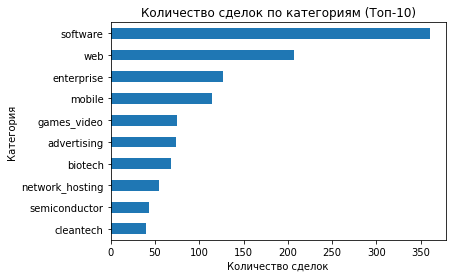

In [ ]:
category_stats['num_deals'].sort_values().plot(
    kind='barh',
    color='#1f77b4',
    title='Количество сделок по категориям (Топ-10)',
    ylabel='Количество',
    xlabel='Категория'

)

plt.xlabel('Количество сделок')
plt.show()

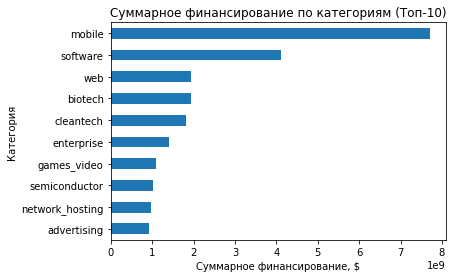

In [ ]:
category_stats['total_funding'].sort_values().plot(
    kind='barh',
    color='#1f77b4',
    title='Суммарное финансирование по категориям (Топ-10)',
    ylabel='Количество',
    xlabel='Категория'

)

plt.xlabel('Суммарное финансирование, $')
plt.show()

По кол-ву сделок в топ-3 входят software, web, enterprise. А по сумме финансирования лидирует mobile, software, web. Категории software, web пересекаются по двум фильтрам, это самые популярные и прибыльные категории для перепродажи.



Построим график по датам финансирования компаний, которые проданы за ноль долларов

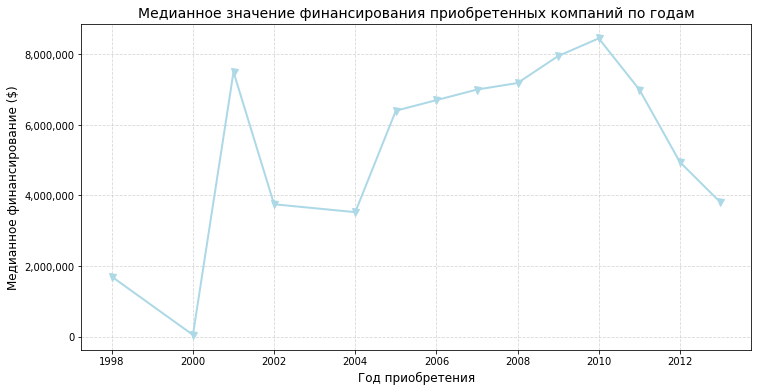

In [ ]:
yearly_median = (low_acqisition[low_acqisition['acquired_at']>1980]
                 .groupby('acquired_at')['funding_total']
                 .median()
                 .sort_index())


# Строим график
plt.figure(figsize=(12, 6))
yearly_median.plot(kind='line',
                   marker='v',
                   color='lightblue',
                   linewidth=2,
                   markersize=7)

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)


plt.title('Медианное значение финансирования приобретенных компаний по годам', fontsize=14)
plt.xlabel('Год приобретения', fontsize=12)
plt.ylabel('Медианное финансирование ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Крупные финансирования наблюдались в 2001, и с 2005 года, финансирование таких компаний увеличивалось. С 2010 идет на спад финансирование компаний, проданных за бесплатно.

Возможно, с 2010 нет интересных предложений на рынке для финансирования, и такие компании за ноль долл покупают для других целей, не для перепродажи. Может для поглощения web или soft технологии по оочень высокой цене. Это видно на графике со средним финансированием по годам покупки ( графие ниже).



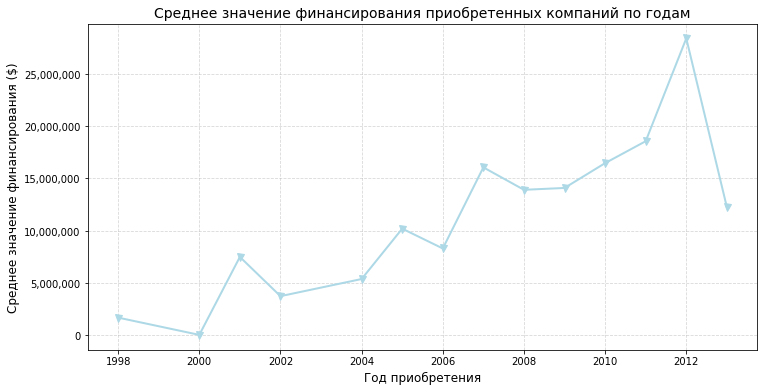

In [ ]:
yearly_mean = (low_acqisition[low_acqisition['acquired_at']>1980]
                 .groupby('acquired_at')['funding_total']
                 .mean()
                 .sort_index())


# Строим график
plt.figure(figsize=(12, 6))
yearly_mean.plot(kind='line',
                   marker='v',
                   color='lightblue',
                   linewidth=2,
                   markersize=7)

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)


plt.title('Среднее значение финансирования приобретенных компаний по годам', fontsize=14)
plt.xlabel('Год приобретения', fontsize=12)
plt.ylabel('Среднее значение финансирования ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

На среднем значении финансирования видно, что в ряд компаний вливают хорошее финасирование для перепродажи за 0 доллар. Тенденция растет.

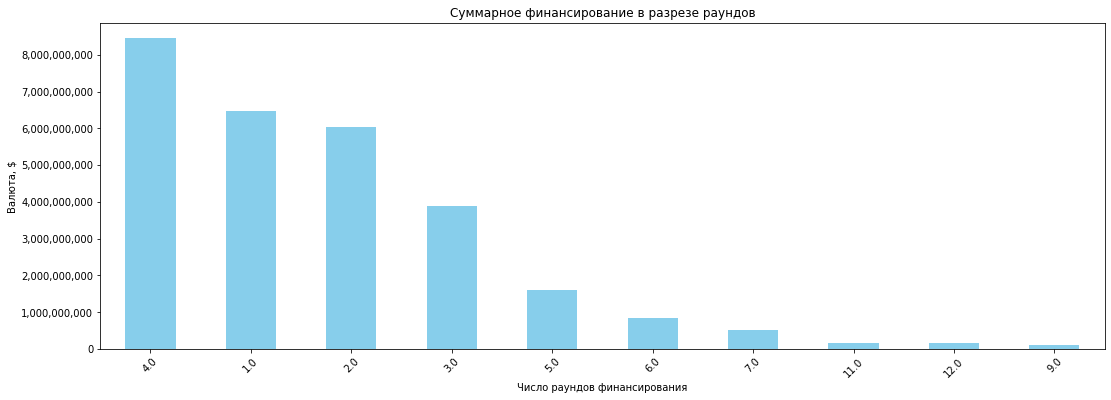

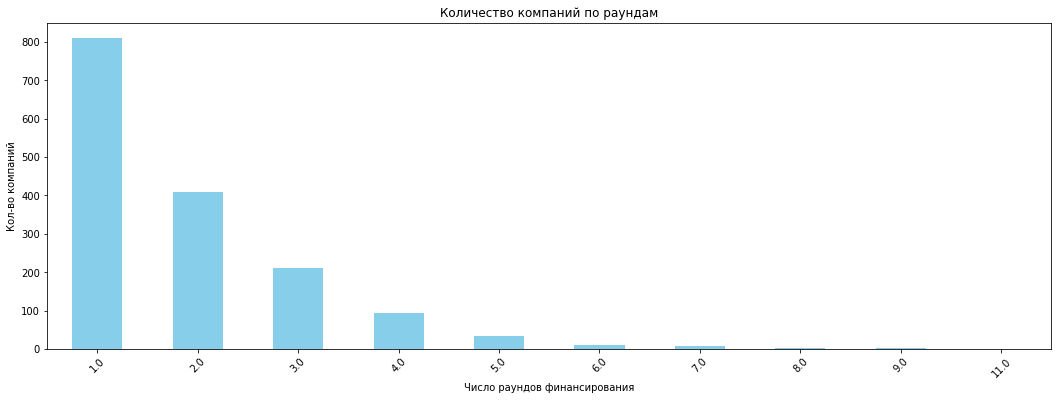

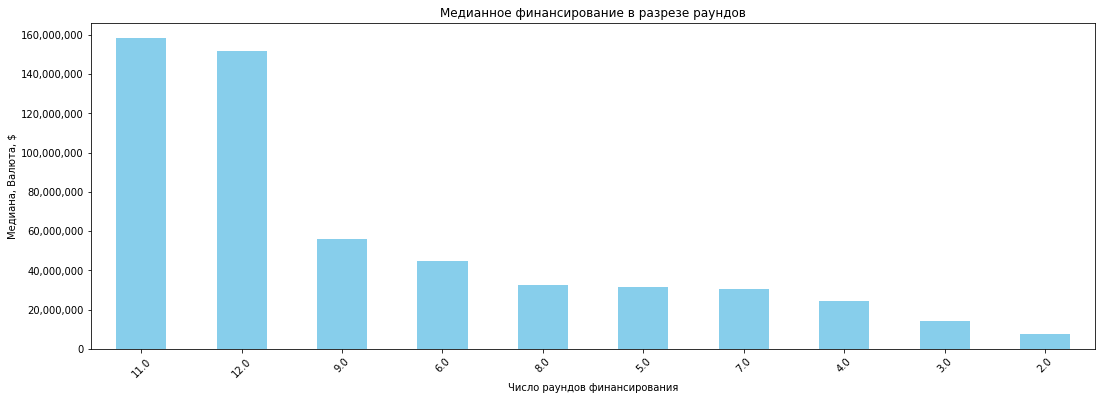

In [ ]:
#Сколько раундов проходит компания до финансирования
# Группировка по раундам
top_rounds = (low_acqisition
                 .groupby('funding_rounds')['funding_total']
                 .sum()
                 .reset_index())

top_sorted = top_rounds.sort_values('funding_total', ascending=False)

median_rounds = (low_acqisition
                 .groupby('funding_rounds')['funding_total']
                 .median()
                 .reset_index())

median_sorted = median_rounds.sort_values('funding_total', ascending=False)

count_rounds = (low_acqisition
                 .groupby('funding_rounds')['funding_total']
                 .count()
                 .reset_index())

count_sorted = count_rounds.sort_values('funding_total', ascending=False)

#Построим столбчатую диаграмму
top_sorted.head(10).plot(kind='bar',
                title='Суммарное финансирование в разрезе раундов',
                legend=False,
                figsize=(18, 6),
                x='funding_rounds',
                y='funding_total',
                ylabel='Валюта, $',
                xlabel='Число раундов финансирования',
                rot=45,
                color='skyblue')

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)


plt.show()

#Построим столбчатую диаграмму
count_sorted.head(10).plot(kind='bar',
                title='Количество компаний по раундам',
                legend=False,
                figsize=(18, 6),
                x='funding_rounds',
                y='funding_total',
                ylabel='Кол-во компаний',
                xlabel='Число раундов финансирования',
                rot=45,
                color='skyblue')

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)

plt.show()


#Построим столбчатую диаграмму
median_sorted.head(10).plot(kind='bar',
                title='Медианное финансирование в разрезе раундов',
                legend=False,
                figsize=(18, 6),
                x='funding_rounds',
                y='funding_total',
                ylabel='Медиана, Валюта, $',
                xlabel='Число раундов финансирования',
                rot=45,
                color='skyblue')

plt.ticklabel_format(style="plain", axis="y")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}")
)

plt.show()

:Чаще всего компании, купленные за 1 или 0 долларов, получали финансирование за один раунд. А самые крупные вливания происходили на длинных раундах 4-11. Это могут быть компании с длинным техническим процессом реализации - software.

В основном, более 50% компаний покупают за 0 долл. при суммарном финансировании в 6 млн долл. И только 10% компаний получили > $35 млн.

1 процент компаний получили от $ 175 млн. до $ 5 млрд.долларов.

Покупают компании за 0 или 1 доллар в среднем за 1 раунд.

Можно сделать выводы, что компании за 0 или 1 долл. покупают сразу, за один раунд и с финансированием 6 млн долл.

По кол-ву сделок в топ-3 входят software, web, enterprise. А по сумме финансирования лидирует mobile, software, web. Категории software, web пересекаются по двум фильтрам, это самые популярные и прибыльные категории для перепродажи.

Возможно, с 2010 нет интересных предложений на рынке для финансирования, и такие компании за ноль долл покупают для других целей. Может для поглощения web или soft технологии. Но ряд компаний получают финансирование в сверх суммах и эта тенденция растет из года в год.


### 3.4. Цены стартапов по категориям

Категории стартапов с типично высокими ценами покупки стартапов и значительным разбросом цен могут быть привлекательными для крупных инвесторов, которые готовы к высоким рискам ради потенциально больших доходов. Среди категорий стартапов выделите категории стартапов, характеризующиеся:

- типично высокими ценами;
- и наибольшим разбросом цен за стартап.

Объясните, почему решили составить топ именно из такого числа категорий и почему рассчитывали именно так.

Найдем топ с типично высокими ценами и наибольшим разбросом, найдем пересечение и выведем топ из этих категорий

In [ ]:
#Возьмем уже подготовленный датасет из предобработки данных
#В целом, в данных у нас только несколько оч крупных компаний-стартапов, они не будут влиять на данные
acqisition_clear.head(5)

,id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,acquiring_company_id,investment_rounds,funding_rounds,funding_total,milestones,price_amount,acquired_at
0,1,Wetpaint,web,operating,2005,-1,wetpaint-inc.com,BachelrWetpaint,USA,NaN,0.0,3.0,3.975000e+07,5.0,NaN,1800
1,4,Digg,news,acquired,2004,-1,digg.com,digg,USA,20953.0,0.0,4.0,4.500000e+07,8.0,500000.0,2012
2,5,Socialnet,social,ipo,2004,-1,socialnet.com,socialnet,USA,NaN,3.0,11.0,2.425700e+09,5.0,NaN,1800
3,7,Omnidrive,network_hosting,closed,2005,2008-09-15 00:00:00,omnidrive.com,Nomadesk,ISR,NaN,0.0,1.0,8.000000e+05,4.0,NaN,1800
4,8,Postini,web,acquired,1999,-1,postini.com,nd,USA,59.0,0.0,0.0,0.000000e+00,0.0,625000000.0,2007


In [ ]:
acqisition_clear.shape

(40747, 16)

In [ ]:
#filtered_startap = filtered_startap.drop('company_id', axis=1)
filtered_startups = acqisition_clear[
    (acqisition_clear['price_amount'] > 0)
].copy()

In [ ]:
filtered_startups['price_amount'].describe(percentiles=[0.75, 0.9, 0.95, 0.99])

count    2.438000e+03
mean     4.428703e+08
std      1.786560e+09
min      1.000000e+00
50%      5.523500e+07
75%      2.615000e+08
90%      7.750000e+08
95%      1.800000e+09
99%      7.400000e+09
max      3.900000e+10
Name: price_amount, dtype: float64

Среднее и медианное значения почти на порядок отличаются, в этом случае в поиске самых групп с типично высокими ценами возьмем медиану

Готовый датасет для анализа.

1. Сгруппируем категории по цене покупки и посчитаем среднее, среднеквадратичное, медиану
Отберем категории, с самой большой медианой
и с самым большим разбросом по размаху
+ возьмем кол-во сделок от 20 штук, поскольку нужн найти типичные категории, подкрепленные кол-вом сделок за весь период, это значит, что спрос есть
2. Найдем топы и объединим

Почему так?

Медиана и среднее разные, поэтому составим топы категорий из медианы, ближе к реальным типичным данным.

Кол-во сделок от 20 рассчитано из медианы по всем сделкам. Код ниже. 50% категорий проводят менее 20 сделок

In [ ]:
category_stats = filtered_startups.groupby('category_code').agg(
    avg_price=('price_amount', 'mean'),
    price_std=('price_amount', 'std'),
    median_price=('price_amount', 'median'),
    deal_count=('price_amount', 'count')
).sort_values('price_std', ascending=False)

# с кол-вом сделок от 10, поскольку нужн найти типичные категории, подкрепленные кол-вом сделок за весь период, это значит, что спрос есть
category_stats = category_stats[category_stats['deal_count'] > 20]
category_stats.head(3)

,avg_price,price_std,median_price,deal_count
category_code,,,,
public_relations,1.868322e+09,6.944051e+09,110000000.0,72
other,5.434797e+08,2.097598e+09,70000000.0,81
biotech,7.362432e+08,1.971955e+09,200000000.0,262


In [ ]:
category_stats['deal_count'].describe()

count     18.000000
mean     128.888889
std      130.081372
min       21.000000
25%       52.750000
50%       79.500000
75%      116.000000
max      471.000000
Name: deal_count, dtype: float64

In [ ]:
# Топы категорий по медианное цене
high_price_categories = category_stats.nlargest(5, 'median_price')

# Топы категорий по разбросу цен (стандартное отклонение)
high_std_categories = category_stats.nlargest(5, 'price_std')

top_risky_categories = pd.concat([
    high_price_categories,
    high_std_categories
]).drop_duplicates()

In [ ]:
top_risky_categories.iloc[0:6, :]

,avg_price,price_std,median_price,deal_count
category_code,,,,
manufacturing,8.137572e+08,1.060435e+09,351000000.0,21
biotech,7.362432e+08,1.971955e+09,200000000.0,262
ecommerce,2.462410e+08,2.823312e+08,180000000.0,49
cleantech,4.881666e+08,8.853835e+08,177500000.0,38
security,6.177786e+08,1.395629e+09,169000000.0,35
public_relations,1.868322e+09,6.944051e+09,110000000.0,72


Вывели топы категорий для всех стартапов, в него вошли manufacturing, biotech, ecommerce, cleantech, public_relations, finance. В этот список вошли категории, у которых самые высокие медианные цены за сделку от 110 млн долл. и разбросом цен от 1 млрд до 6 млрд долларов. В списке категории с небольшим кол-вом сделок в среднем 20-60 и большим кол-вом от 70-260.


### 3.5. Сколько раундов продержится стартап перед покупкой

- Необходимо проанализировать столбец `funding_rounds`. Исследуйте значения столбца. Заказчика интересует типичное значение количества раундов для каждого возможного статуса стартапа.
- Постройте график, который отображает, сколько в среднем раундов финансирования проходило для стартапов из каждой группы. Сделайте выводы.

In [ ]:
#данные из обработанного файла
filtered_companies.shape

(40747, 13)

In [ ]:
filtered_companies['funding_rounds'].describe(percentiles=[0.75, 0.9, 0.95, 0.99])

count    40747.000000
mean         1.291531
std          1.264604
min          0.000000
50%          1.000000
75%          2.000000
90%          3.000000
95%          4.000000
99%          6.000000
max         15.000000
Name: funding_rounds, dtype: float64

50% стартапов покупают за один раунд.Только 10% компаний продерживаются до 3 раунда. 1% компаний даже до 6 раундов.

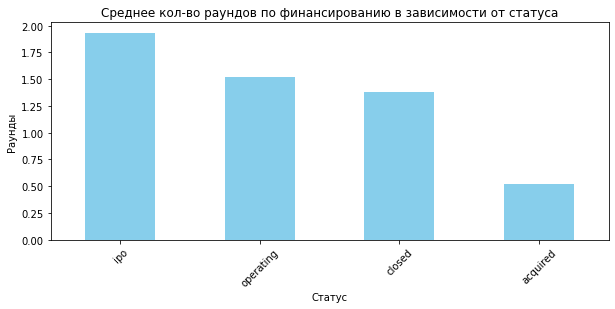

In [ ]:
#Сколько раундов в среднем проходит стартап до финансирования
# Группировка по раундам
rounds_startup = (filtered_companies
                 .groupby('status')['funding_rounds']
                 .mean()
                 .reset_index()
                 .query("status != 'nd'"))

rounds_sorted = rounds_startup.sort_values('funding_rounds', ascending=False)

#Построим столбчатую диаграмму
rounds_sorted.plot(kind='bar',
                title='Среднее кол-во раундов по финансированию в зависимости от статуса',
                legend=False,
                figsize=(10, 4),
                x='status',
                y='funding_rounds',
                ylabel='Раунды',
                xlabel='Статус',
                rot=45,
                color='skyblue')


plt.show()

При статусе ipo и operating кол-во раундов стремится к 2. Стартапы в статусе
Closed держатся один раунд. Статус acquired типично, что даже не доходят до раунда, компанию покупают раннее.

Подтверждается, что при ipo больше нужно времени с последовательным ростом.
Для operating статуса типичны доп.вливания и раунды увеличиваются.

А closed типично, что закрываются после первого провального раунда.
Статус acquired типично, что даже не доходят до раунда, компанию покупают раннее. Если посмотреть медиану, то 50% = 0.



In [ ]:
filtered_companies.groupby('status')['funding_rounds'].agg(['mean', 'median']).query("status != 'nd'")

,mean,median
status,,
acquired,0.523526,0.0
closed,1.381453,1.0
ipo,1.934375,1.0
operating,1.522658,1.0



## Шаг 4. Итоговый вывод и рекомендации

Исследование показало, что выбранные компании, которые готовы менять владельцев, могут получить достаточно разное финансирование. Типичным для компании считается финансирование в 600 тыс долл. несмотря на присутствие больших сумм. Компании, получившие финансирование от 14 млн. долл. указывают на нетипичное поведение в торгах. Компании, которые получают высокое финансирование от 133 млн долл – 1%.

Дальше рассмотрели компании, которые были куплены за ноль или доллар. Такие компании отличает высокое финансирование, больше, чем у обычных. Около 50% компаний получили финансирование в 6 млн.долл. В такой группе присутствуют огромные компании с вложением до 5 млрд долл. Компании с финансированием от 33 млн долл относятся к аномально высоким. Их 10% от всех. Категории software, web пересекаются по двум фильтрам, это самые популярные и прибыльные категории для перепродажи. Крупные финансирования наблюдались в 2001, и с 2005 года, финансирование таких компаний увеличивалось. С 2010 идет на спад финансирование компаний по медианной цене, но продолжаюттся покупки по оч высоким ценам.

Возможно, с 2010 нет интересных предложений на рынке для финансирования, и такие компании за ноль долл покупают для других целей, не для перепродажи. Может для поглощения web или soft технологии по оочень высокой цене.

В стартапах выделили самые высокие медианные цены за сделку от 110 млн долл. Категории, вошедшие в список: manufacturing, biotech, ecommerce, cleantech, public_relations, finance. При статусе ipo и operating кол-во раундов стремится к 2. Стартапы в статусе Closed за один раунд. Статус acquired типично, что даже не доходят до раунда, компанию покупают раннее. Данные подкрепляют друг друга.

Рекомендации:

После проведенного анализа выявлены некоторые критерии по выбору стартапа/компании для следующей перепродажи:
1) Финансирование:
- основной рынок, от 0 до 14 млн долл. Обычно в компании финансируются в 600 тыс долл.

- Рынок стартапов с высокими ценами от 100 млн долл. Для рисковой покупки стартапа нужно обратить внимание на категории с высокой медианой: manufacturing, biotech, ecommerce, cleantech, public_relations, finance. Разброс цен от 1 млрд до 6 млрд долларов.

- Интересен сегмент компаний, проданных за 0 или 1 долл. – часто имеют высокое финансирование (медиана 6 млн долл), но могут быть убыточными или формальными сделками. Рынок по средним финансовым вливаниям немного падает, но компании с высокими финансовыми вложениями растут. Можно купить очень дорогую компанию за 0 долл.

2) Количество раундов финансирования:

- 50% стартапов продаются после 1 раунда.
- ipo или operating – обычно 2+ раунда.
- acquired – часто покупают без раундов, можно найти дешевые, но ценные активы

3) Категории для покупки:
- manufacturing, biotech, ecommerce, cleantech, public_relations, finance – дорогие, но рискованные. Категория biotech - самая популярная для сделок.
- Для компаний, продающихся за 0 или 1 долл: категории sofware, web прибыльные для перепродажи.

Обращаться внимание:
- Большое кол-во раундов, компания может не справляться с финансовой нагрузкой , но еще это знак, что она получит большое финансирование
- Компании, проданные за 0 или доллар, могут быть с долгами

